### MiddleWare

Middleware provides a way to more tightly control what happens inside the agent. Middleware is useful for the following:

1. Tracking agent behavior with logging, analytics, and debugging.
2. Transforming prompts, tool selection, and output formatting.
3. Adding retries, fallbacks, and early termination logic.
4. Applying rate limits, guardrails, and PII detection.

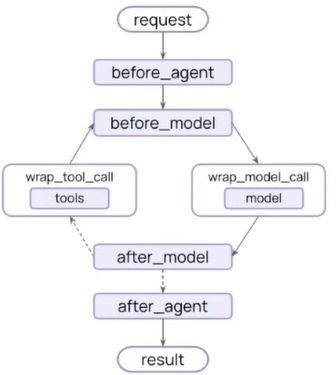

In an AI agent context, middleware is the layer between the agent's reasoning and the tool execution.

Hooks are predefined points in a workflow where you can run your own code before, after, or around an action.
    
Think of them as "interception points" in the execution flow.

### Summarization MiddleWare

Automatically summarize conversation history when approaching token limits, preserving recent messages while compressing older
context. Summarization is useful for the following:

1. Long-running conversations that exceed context windows.
2. Multi-turn dialogues with extensive history.
3. Applications where preserving full conversation context matters.

In [9]:
from langchain_groq import ChatGroq
import os

llm = ChatGroq(
    model="qwen/qwen3-32b",
    api_key=os.getenv("GROQ_API_KEY"),
    max_tokens = 500
)

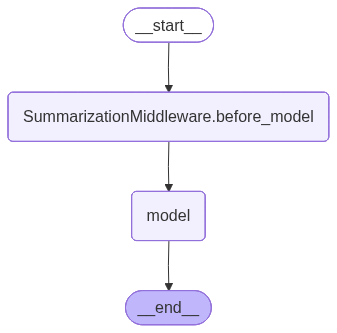

In [10]:
from langchain.agents import create_agent
from langchain.agents.middleware import SummarizationMiddleware
from langgraph.checkpoint.memory import InMemorySaver
from langchain_core.messages import HumanMessage, SystemMessage

# Agent with Message Based Summarization

agent = create_agent(
    model = llm,
    checkpointer = InMemorySaver(),
    middleware = 
    [   
        SummarizationMiddleware(model = llm,
                                trigger = ("messages", 10),
                                keep = ("messages", 4))
    ]
)

agent

In [11]:
##Thread ID for unique session ID
config = {"configurable" : {"thread_id": "test1"}}

In [12]:
##Alternate Test Data

questions = [
    "What is 2 + 2",
    "What is 10*5",
    "What is 100/4",
    "What is 15-7",
    "What is 4*4",
    "What is 3*2"
]

for q in questions:
    response = agent.invoke({"messages": [HumanMessage(content = q)]},config)
    print(f"Messages: {response}")
    print(f"Messages: {len(response['messages'])}")

Messages: {'messages': [HumanMessage(content='What is 2 + 2', additional_kwargs={}, response_metadata={}, id='55cd0078-5298-408a-ba93-7534ff1b3d48'), AIMessage(content='<think>\nOkay, so the user is asking "What is 2 + 2". Hmm, that\'s a basic arithmetic question. Let me make sure I understand it correctly. The problem is straightforward: adding two and two.\n\nFirst, I need to recall the basic addition facts. 2 plus 2 is something I learned early on. Let me visualize it. If I have two apples and I get two more apples, how many do I have in total? That would be four apples. So, 2 + 2 equals 4. \n\nWait, but maybe the user is expecting something more? Sometimes people ask this question as a joke or to test if someone is paying attention. For example, there\'s a famous joke where someone says 2 + 2 is 5, but that\'s not the correct answer. The correct answer is definitely 4. \n\nI should also consider if there\'s any trick here. Maybe in some contexts, like in modular arithmetic, 2 + 2 c

### Token Size Summarisation

In [13]:
from langchain.agents import create_agent
from langchain_core.messages import HumanMessage, SystemMessage
from langchain.agents.middleware import SummarizationMiddleware
from langchain_core.tools import tool
from langgraph.checkpoint.memory import InMemorySaver

@tool
def search_hotels(city : str) -> str:
    "Search Hotels - return long responses to use more tokens."
    return f"""Hotels in {city}
    1. Grand Hotel - 5 star, $350/night, spa, pool, gym
    2. City Inn - 4 star, $180/night, business center
    3. Budget Stay - 3 star, $75, free WiFi"""

agent = create_agent(
    model = llm,
    tools = [search_hotels],
    checkpointer = InMemorySaver(),
    middleware = [
        SummarizationMiddleware(
            model = llm,
            trigger = ("tokens", 550),
            keep = ("tokens", 200)
        )
    ]
)

config = {"configurable": {"thread_id" : "test-1"}}

def count_tokens(messages):
    total_chars = sum(len(str(m.content)) for m in messages)
    return total_chars // 4  #4 characters = 1 token

In [14]:
cities = ["Paris", "London", "Tokyo", "New York", "Dubai", "Singapore"]

for city in cities:
    response = agent.invoke(
        {"messages" : [HumanMessage(content = f"Find Hotels in {city}")]},
        config = config
    )

    tokens = count_tokens(response["messages"])    
    print(f"{city}: ~{tokens} tokens, {len(response['messages'])} messages")
    print(f"{(response['messages'])}")

Paris: ~162 tokens, 4 messages
[HumanMessage(content='Find Hotels in Paris', additional_kwargs={}, response_metadata={}, id='f0c13abb-5a18-4c7b-aac4-b721e58cb168'), AIMessage(content='', additional_kwargs={'reasoning_content': 'Okay, the user is asking to find hotels in Paris. Let me check the available tools. There\'s a function called search_hotels that takes a city parameter. The required parameter is city, and it\'s a string. Since the user specified Paris, I need to call this function with "Paris" as the city argument. I should make sure the JSON is correctly formatted with the city name in quotes. No other parameters are needed here. Let me structure the tool call accordingly.\n', 'tool_calls': [{'id': '39bdqxw2j', 'function': {'arguments': '{"city":"Paris"}', 'name': 'search_hotels'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 122, 'prompt_tokens': 155, 'total_tokens': 277, 'completion_time': 0.174541768, 'completion_tokens_details': {'reasoni

### Fraction based Summarization

In [15]:
from langchain.agents import create_agent
from langchain_core.messages import HumanMessage, SystemMessage
from langchain.agents.middleware import SummarizationMiddleware
from langchain_core.tools import tool
from langgraph.checkpoint.memory import InMemorySaver

@tool
def search_hotels(city : str) -> str:
    "Search Hotels - return long responses to use more tokens."
    return f"""Hotels in {city}
    1. Grand Hotel - 5 star, $350/night, spa, pool, gym
    2. City Inn - 4 star, $180/night, business center
    3. Budget Stay - 3 star, $75, free WiFi"""

agent = create_agent(
    model = llm,
    tools = [search_hotels],
    checkpointer = InMemorySaver(),
    middleware = [
        SummarizationMiddleware(
            model = llm,
            trigger = ("fraction", 0.005),  # 0.5% token limit
            keep = ("tokens", 200)          # 0.2% keeps token 
        )
    ]
)

config = {"configurable": {"thread_id" : "test-1"}}

def count_tokens(messages):
    total_chars = sum(len(str(m.content)) for m in messages)
    return total_chars // 4  #4 characters = 1 token

In [16]:
cities = ["Paris", "London", "Tokyo", "New York", "Dubai", "Singapore"]

for city in cities:
    response = agent.invoke(
        {"messages" : [HumanMessage(content = f"Find Hotels in {city}")]},
        config = config
    )

    tokens = count_tokens(response["messages"])    
    print(f"{city}: ~{tokens} tokens, {len(response['messages'])} messages")
    print(f"{(response['messages'])}")

Paris: ~154 tokens, 4 messages
[HumanMessage(content='Find Hotels in Paris', additional_kwargs={}, response_metadata={}, id='40c74f29-ad99-45b8-8310-785abcd45b7c'), AIMessage(content='', additional_kwargs={'reasoning_content': 'Okay, the user wants to find hotels in Paris. Let me check the available tools. There\'s a function called search_hotels that takes a city parameter. The city here is Paris. I need to make sure the function is called correctly. The parameters should be {"city": "Paris"}. Since the function is supposed to return long responses, I don\'t need to worry about the response length. Just need to structure the tool call properly. Let me verify the JSON format. The name should be "search_hotels" and the arguments should be a JSON object with the city. Everything looks good. Alright, time to output the tool call.\n', 'tool_calls': [{'id': 'yjq6b6znc', 'function': {'arguments': '{"city":"Paris"}', 'name': 'search_hotels'}, 'type': 'function'}]}, response_metadata={'token_u

### Human in the Loop - Middleware

Pause agent execution for human approval, editing, or rejection of tool calls before they execute. Human-in-the-loop is useful for the following:

1. High-stakes operations requiring human approval (e.g. database writes, financial transactions).
2. Compliance workflows where human oversight is mandatory.
3. Long-running conversations where human feedback auides the agent.

In [49]:
from langchain.agents import create_agent
from langchain.agents.middleware import HumanInTheLoopMiddleware
from langgraph.checkpoint.memory import InMemorySaver

def read_email_tool(email_id : str) -> str:
    """Mock function to read an email by its ID"""
    return f"Email content for ID: {email_id}"

def send_email_tool(recipient: str, subject: str, body: str) -> str:
    """Mock function to send an email"""
    return f"Email sent to {recipient} with subject {subject}"

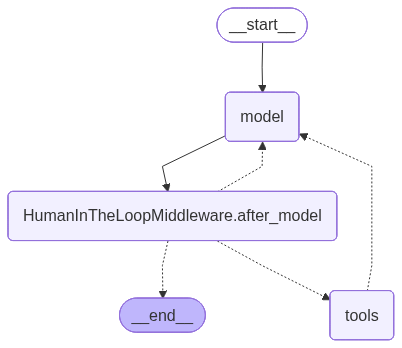

In [50]:
agent = create_agent(
    model = llm,
    tools = [read_email_tool, send_email_tool],
    checkpointer = InMemorySaver(),
    middleware= [HumanInTheLoopMiddleware(
        interrupt_on = {
            "send_email_tool":{"allowed_decisions" : ["approve", "edit", "reject"]},
            "read_email_tool":False,
        }
    )]
)

agent

In [51]:
config = {"configurable" : {"thread_id" : "test-approve"}}

#Step - 1 Request
result = agent.invoke(
    {"messages" : [HumanMessage(content = "Send Email to john@test.com with subject 'Hello' and body 'How are you!'")]},
    config = config
)

In [52]:
result

{'messages': [HumanMessage(content="Send Email to john@test.com with subject 'Hello' and body 'How are you!'", additional_kwargs={}, response_metadata={}, id='a97798f1-0509-4821-8a59-94415f171b36'),
  AIMessage(content='', additional_kwargs={'reasoning_content': "Okay, the user wants to send an email to john@test.com with the subject 'Hello' and body 'How are you!'. Let me check the available tools. There's a send_email_tool that requires recipient, subject, and body. All three are required. The parameters are provided in the user's request. So I need to call send_email_tool with those arguments. No need to use read_email_tool here since the user isn't asking to read an email. Just construct the JSON with the given parameters and make the tool call.\n", 'tool_calls': [{'id': 'dw3cdvare', 'function': {'arguments': '{"body":"How are you!","recipient":"john@test.com","subject":"Hello"}', 'name': 'send_email_tool'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_toke

In [29]:
#Step 2 Approve the interrupt

from langgraph.types import Command

if "__interrupt__" in result:
    print("Approving")

    result = agent.invoke(Command( resume = {"decisions" : [{"type" : "approve"}]}), config = config)

    print(f"Result: {result["messages"][-1].content}")

Approving
Result: The email with the subject "Hello" has been successfully sent to john@test.com with the body "How are you!". Let me know if you need anything else!


In [35]:
#Step 3 Reject the Interrupt

from langgraph.types import Command

if "__interrupt__" in result:
    print("Rejecting")

    result = agent.invoke(Command( resume = {"decisions" : [{"type" : "reject"}]}), config = config)

    print(f"Result: {result["messages"][-1].content}")

Rejecting
Result: The tool call to send the email was rejected by the user. The email to **john@test.com** with subject "Hello" was **not sent**. Would you like to retry this request or adjust the message? Let me know how I can assist further.


In [53]:
#Step 4 Editing the Interrupt

from langgraph.types import Command

if "__interrupt__" in result:
    print("Editing")

    result = agent.invoke(Command
                            ( 
                                resume = 
                                    {
                                        "decisions" : 
                                        [{
                                            "type" : "edit",    
                                            "edited_action" : {
                                                "name" : "send_email_tool",     #Tool Name
                                                "args" : {                      #Corrected Action
                                                    "recepient" : "correct@gmail.com",
                                                    "subject" : "Corrected Subject",
                                                    "body" : "This was edited by human in the loop"
                                                }
                                            }
                                        }]
                                    }
            ), 
        config = config
    )

    print(f"Result: {result["messages"]}")

Editing
Result: [HumanMessage(content="Send Email to john@test.com with subject 'Hello' and body 'How are you!'", additional_kwargs={}, response_metadata={}, id='a97798f1-0509-4821-8a59-94415f171b36'), AIMessage(content='', additional_kwargs={'reasoning_content': "Okay, the user wants to send an email to john@test.com with the subject 'Hello' and body 'How are you!'. Let me check the available tools. There's a send_email_tool that requires recipient, subject, and body. All three are required. The parameters are provided in the user's request. So I need to call send_email_tool with those arguments. No need to use read_email_tool here since the user isn't asking to read an email. Just construct the JSON with the given parameters and make the tool call.\n", 'tool_calls': [{'id': 'dw3cdvare', 'function': {'arguments': '{"body":"How are you!","recipient":"john@test.com","subject":"Hello"}', 'name': 'send_email_tool'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tok